# Week 4: Exploratory Data Analysis (EDA)
## Objectives
- Know how to standardize the numeric variables
- Know how to choose the optimal visualization tool to analyze the co-variation of two variables in Python 

### Standardizing the Numeric Fields

Here we use the Dimamond data set to illustrate, as we will do data exploration also on that data set.

- To import the data set, we should include *statsmodels* library.
- To plot a figure, we need another library *matplotlib*.
- *Pandas* is a powerful and widely library for data manipulation and analysis. 

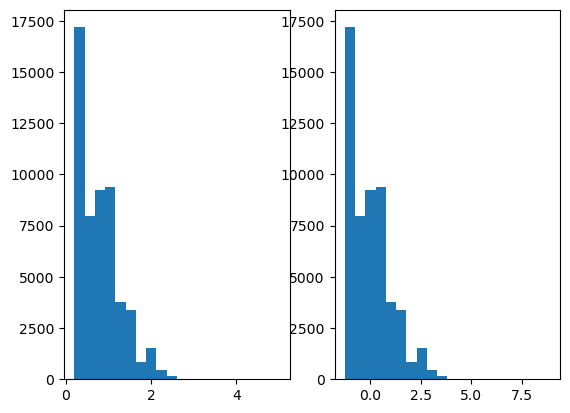

In [2]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
diamond = sm.datasets.get_rdataset("diamonds", "ggplot2")
df = pd.DataFrame(data = diamond.data)
df.head()
fig,(ax1,ax2)= plt.subplots(1, 2)
ax1.hist(df['carat'],bins = 20)
df['carat_z'] = stats.zscore(df['carat'])
ax2.hist(df['carat_z'],bins =20)
plt.show()

## Exploratory Data Analysis (EDA)


### Visualization on Two Continuous Variables

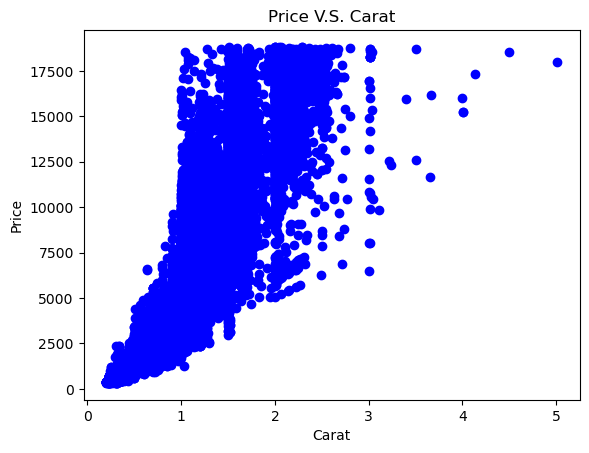

In [9]:
# Create a scatter plot
plt.scatter(df['carat'],df['price'], color='blue', marker='o')
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Price V.S. Carat")
plt.show()

How to do a *Pearson* correlation? Here we use the function in **panda**.

In [10]:
r = df["carat"].corr(df["price"], method="pearson")
print("Pearson r:", r)

Pearson r: 0.9215913011934771


To also show the example of *Iris* data set, we need to import the *seaborn* package.

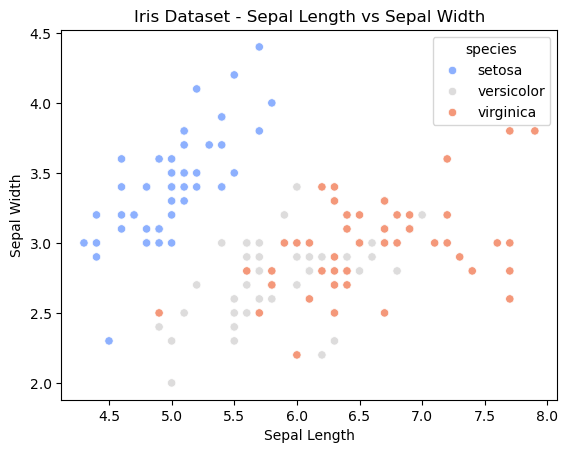

In [4]:
import seaborn as sns
# Load the Iris dataset
iris = sns.load_dataset("iris")
# Scatter plot of sepal_length vs sepal_width with species as color
sns.scatterplot(x="sepal_length", y="sepal_width", hue="species", data=iris, palette="coolwarm")
plt.title("Iris Dataset - Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

To generate the coefficient matrix, we can also use *.corr()*.

In [11]:
iris.corr(method="pearson")

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


### Visualization on One Continuous and One Categorical Variable using Histogram Overlay

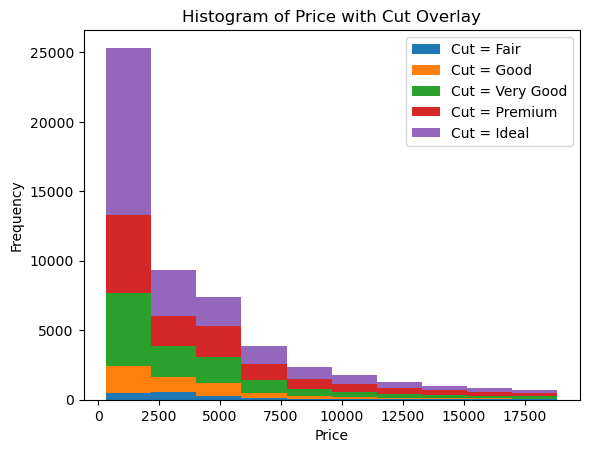

In [12]:
cut_fair = df[df.cut == "Fair"]['price']
cut_good = df[df.cut == "Good"]['price']
cut_vg = df[df.cut == "Very Good"]['price']
cut_premium = df[df.cut == "Premium"]['price']
cut_ideal = df[df.cut == "Ideal"]['price']
plt.hist([cut_fair,cut_good,cut_vg,cut_premium,cut_ideal], bins = 10, stacked = True)
plt.legend(['Cut = Fair', 'Cut = Good','Cut = Very Good','Cut = Premium', 'Cut = Ideal'])
plt.title('Histogram of Price with Cut Overlay')
plt.xlabel('Price'); plt.ylabel('Frequency'); 
plt.show()

### Visualization on One Continuous and One Categorical Variable using Boxplot

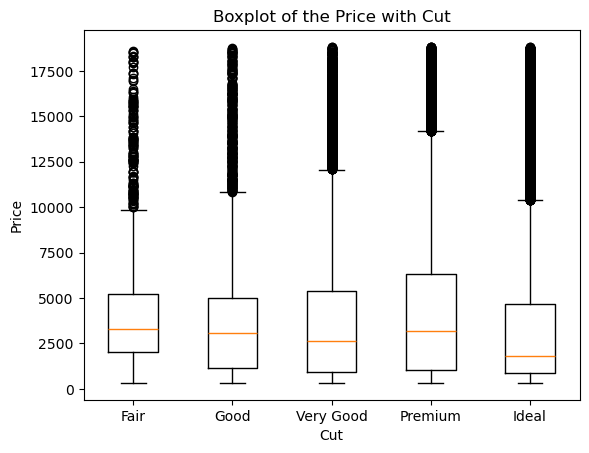

In [13]:
plt.boxplot([cut_fair,cut_good,cut_vg,cut_premium,cut_ideal])
plt.title("Boxplot of the Price with Cut")
plt.xticks([1, 2, 3, 4,5], ["Fair", "Good", "Very Good", "Premium","Ideal"])  # Custom labels
plt.xlabel('Cut'); plt.ylabel('Price'); 
plt.show()

### Visualization on Two Categorical Variables

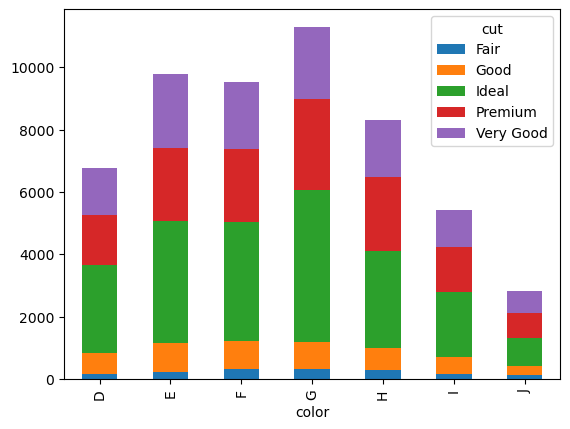

In [14]:
crosstab = pd.crosstab(df['color'],df['cut'])
crosstab.plot(kind='bar',stacked = True)
plt.show()

We can create a normalized version.

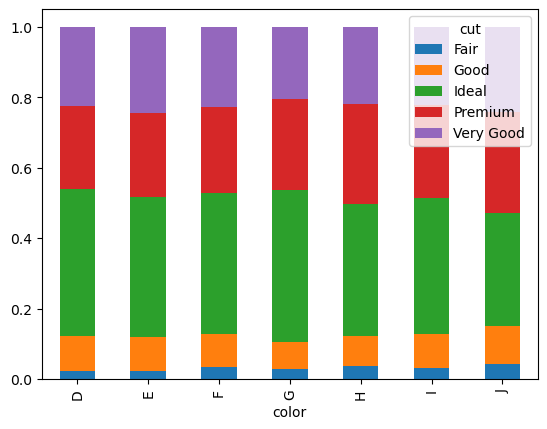

In [15]:
#To create the normalized version of barplot
crosstab_norm = crosstab.div(crosstab.sum(1),axis =0)
crosstab_norm.plot(kind='bar',stacked = True) 
plt.show()